ESERCIZIO

Implementa un Autoecndoer classico su MNIST
1) Crea un bottleneck di solo 2 neuroni
2) Visualizza lo scatter plot dello spazio latente colorando i punti per classe
3) Prova a campionare un punto a caso tra due cluster e osserva la ricostruzione 
Suggerimento: usa 'model.layer' per estrarre l'encoder e il decoder come modelli separati.

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.02MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 327kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.82MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.51MB/s]


Inizio della fase di training...
Epoca [1/10], Loss Media: 0.2268
Epoca [2/10], Loss Media: 0.1814
Epoca [3/10], Loss Media: 0.1710
Epoca [4/10], Loss Media: 0.1654
Epoca [5/10], Loss Media: 0.1621
Epoca [6/10], Loss Media: 0.1594
Epoca [7/10], Loss Media: 0.1573
Epoca [8/10], Loss Media: 0.1559
Epoca [9/10], Loss Media: 0.1544
Epoca [10/10], Loss Media: 0.1533


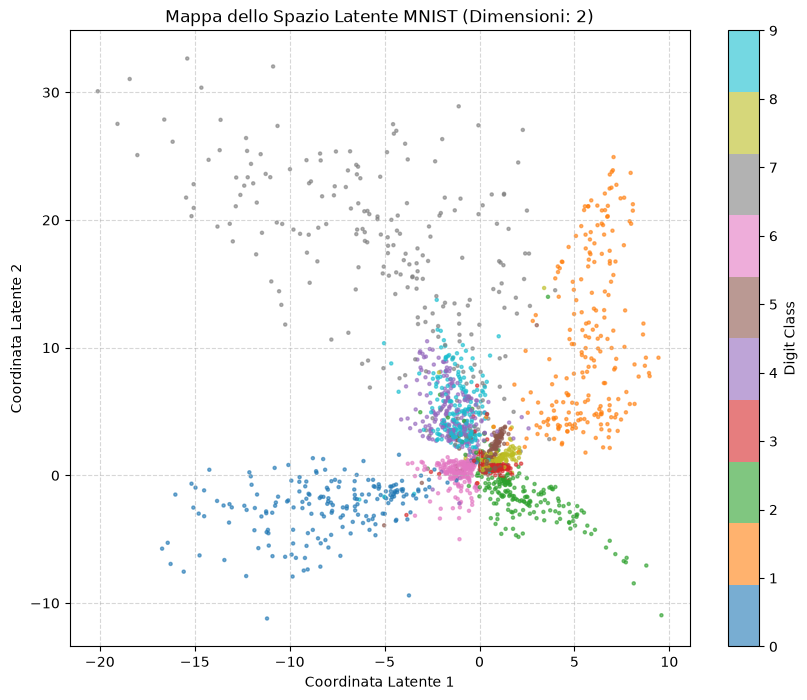

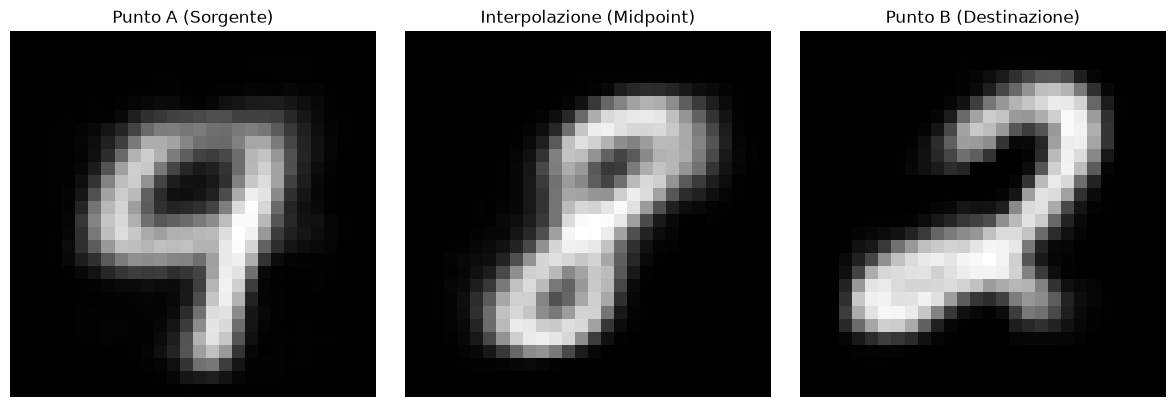

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# 1. Configurazione dell'ambiente e preparazione dei dati
# Determiniamo il dispositivo di calcolo (GPU se disponibile, altrimenti CPU).
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Definiamo la trasformazione dei dati:
# - ToTensor: converte le immagini PIL in tensori PyTorch scalando i pixel da [0, 255] a [0, 1].
# - Normalize: sposta il range da [0, 1] a [-1, 1] per allinearsi con la funzione di attivazione Tanh del decoder.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Carichiamo il dataset MNIST (cifre scritte a mano) per l'addestramento.
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# 2. Architettura dell'Autoencoder
# Un autoencoder è composto da due parti simmetriche: un Encoder che comprime e un Decoder che ricostruisce.
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        # L'Encoder riduce la dimensionalità da 784 (28x28 pixel) a soli 2 parametri.
        # Questo "bottleneck" (collo di bottiglia) forza la rete a imparare solo le caratteristiche salienti.
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 2)  # Spazio latente a 2 dimensioni per facile visualizzazione
        )
        
        # Il Decoder prende le 2 coordinate latenti e tenta di espanderle nuovamente in un'immagine completa.
        self.decoder = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Tanh()  # Tanh restituisce valori tra -1 e 1, coerenti con i dati normalizzati
        )

    def forward(self, x):
        # Flattening dell'immagine: da (batch, 1, 28, 28) a (batch, 784).
        z = self.encoder(x.view(-1, 28 * 28))
        reconstructed = self.decoder(z)
        # Restituiamo l'immagine ricostruita (riportata alla forma originale) e il vettore latente z.
        return reconstructed.view(-1, 1, 28, 28), z

# Inizializzazione del modello, della funzione di perdita (MSE) e dell'ottimizzatore (Adam).
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Addestramento del Modello
print("Inizio della fase di training...")
epochs = 10
for epoch in range(epochs):
    total_loss = 0
    for images, _ in train_loader:
        images = images.to(device)
        
        # Otteniamo la ricostruzione e calcoliamo l'errore rispetto all'originale.
        recon, _ = model(images)
        loss = criterion(recon, images)
        
        # Backpropagation e aggiornamento dei pesi.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoca [{epoch+1}/{epochs}], Loss Media: {avg_loss:.4f}")

# 4. Analisi dello Spazio Latente
# Visualizziamo come il modello ha organizzato le diverse cifre nel piano 2D.
model.eval()
all_z, all_y = [], []
with torch.inference_mode():
    # Usiamo un subset di 2000 campioni per la visualizzazione.
    visual_loader = DataLoader(train_dataset, batch_size=2000)
    images, labels = next(iter(visual_loader))
    _, z = model(images.to(device))
    all_z = z.cpu().numpy()
    all_y = labels.numpy()

plt.figure(figsize=(10, 8))
scatter = plt.scatter(all_z[:, 0], all_z[:, 1], c=all_y, cmap='tab10', alpha=0.6, s=5)
plt.colorbar(scatter, ticks=range(10), label='Digit Class')
plt.title("Mappa dello Spazio Latente MNIST (Dimensioni: 2)")
plt.xlabel("Coordinata Latente 1")
plt.ylabel("Coordinata Latente 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 5. Generazione per Interpolazione (Morphing)
# Qui dimostriamo come il Decoder possa "inventare" immagini navigando tra le coordinate latenti.
with torch.inference_mode():
    # Definiamo due punti nello spazio latente basandoci sui cluster osservati nel grafico precedente.
    # Ad esempio, se il cluster dei '1' è intorno a (-2, 5) e quello degli '0' a (5, -2).
    point_a = torch.tensor([[-2.0, 5.0]], device=device)
    point_b = torch.tensor([[5.0, -2.0]], device=device)
    
    # Calcoliamo il punto medio matematico: questo rappresenta una cifra "ibrida".
    mid_point = (point_a + point_b) / 2

    # Utilizziamo solo il Decoder per generare le immagini partendo dai vettori latenti.
    gen_a = model.decoder(point_a).view(28, 28).cpu()
    gen_mid = model.decoder(mid_point).view(28, 28).cpu()
    gen_b = model.decoder(point_b).view(28, 28).cpu()

# Visualizzazione del processo di interpolazione.
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gen_a, cmap='gray')
axes[0].set_title("Punto A (Sorgente)")
axes[0].axis('off')

axes[1].imshow(gen_mid, cmap='gray')
axes[1].set_title("Interpolazione (Midpoint)")
axes[1].axis('off')

axes[2].imshow(gen_b, cmap='gray')
axes[2].set_title("Punto B (Destinazione)")
axes[2].axis('off')

plt.tight_layout()
plt.show()